In [ ]:
Aluna: Marja Tanita de Oliveira Ramos Gringel
Professores Orientadores: Sérgio Monteiro, D.Sc.; Manuel Martins, D.Sc.
Disciplinas: Fundamentos de Estatística Aplicada e Linguagem de Programação Aplicada R
Trabalho Prático: Estatística e Probabilidade Aplicada à Astronomia

***Este notebook realiza a simulação de 1000 observações de brilho estelar, análise descritiva, inferência estatística e diagnóstico de outliers.***

# Análise Estatística do Brilho Estelar — Simulação, Inferência e Outliers

**************************************************************************
Professores Orientadores: Sérgio Monteiro, D.Sc.; Manuel Martins, D.Sc.

Aluna: Marja Tanita de Oliveira Ramos gringel
**************************************************************************

Este projeto realiza uma análise estatística completa sobre dados simulados de brilho estelar.  
O objetivo é verificar se os dados seguem o modelo teórico assumido, aplicar métodos de inferência e avaliar o impacto de outliers.

---

## 📌 Objetivos do Projeto

- Simular 1000 observações de brilho estelar seguindo uma distribuição normal.
- Visualizar a distribuição dos dados por meio de histogramas, boxplots e QQ-plots.
- Calcular estatísticas descritivas básicas.
- Construir intervalos de confiança (IC) para a média.
- Realizar testes de hipótese (t e z) comparando a média amostral com a média teórica.
- Identificar outliers usando métodos estatísticos (IQR e Z-score).
- Avaliar o impacto dos outliers na média.
- Interpretar os resultados de forma pedagógica.

---

## 🧪 Metodologia

1. **Simulação dos dados**  
   Os dados foram gerados usando `rnorm()`, assumindo:
   - média teórica: 15.5  
   - desvio padrão do telescópio: 0.8  
   - tamanho da amostra: 1000  

2. **Visualização**  
   Foram criados:
   - Histograma com densidade e curva normal teórica  
   - Boxplot  
   - QQ-plot  

3. **Inferência estatística**  
   - Estatísticas descritivas  
   - Intervalos de confiança (t e z)  
   - Teste t  
   - Teste z manual  

4. **Diagnóstico de outliers**  
   - Método do IQR (1.5 × IQR)  
   - Método do Z-score (|z| > 3)  
   - Comparação da média com e sem outliers  

---

## 📂 Estrutura do Notebook

1. **Simulação dos Dados**  
   Geração da amostra e criação do data frame.

2. **Visualização da Distribuição**  
   Gráficos para avaliar normalidade e possíveis valores extremos.

3. **Inferência Estatística**  
   ICs, testes t e z, e estatísticas descritivas.

4. **Outliers**  
   Identificação, análise e impacto na média.

5. **Conclusão**  
   Síntese dos resultados e interpretação final.

---

## 📊 Resultados Resumidos

- A média amostral ficou muito próxima da média teórica (15.5).
- Os intervalos de confiança (t e z) incluíram o valor teórico.
- Os testes t e z apresentaram valores-p altos → **não rejeitamos H0**.
- Os dados simulados são compatíveis com a distribuição normal assumida.
- Outliers foram identificados pelos métodos IQR e Z-score.
- A média sem outliers ficou ainda mais próxima da média teórica.
- Outliers podem distorcer a média e aumentar a variabilidade.

---

## ▶️ Como Executar

1. Abra o notebook no Google Colab.
2. Execute a célula de instalação de pacotes **apenas se necessário**.
3. Execute as células em ordem.
4. Observe os gráficos, tabelas e interpretações.

---

## 🧾 Conclusão

A análise confirma que os dados simulados seguem adequadamente o modelo normal proposto.  
Os intervalos de confiança e testes de hipótese mostram que a média amostral é compatível com o valor teórico.  
A identificação de outliers evidencia que valores extremos podem influenciar a média e o desvio padrão, reforçando a importância de reportar resultados **com e sem outliers**.

O estudo demonstra como ferramentas estatísticas podem validar modelos teóricos e avaliar a qualidade dos dados.

---



In [4]:
# ------------------------------------------------------------
# Configuração inicial do ambiente
# ------------------------------------------------------------

# Parâmetros teóricos da simulação
n <- 1000                 # tamanho da amostra
mu_teorico <- 15.5        # média teórica do brilho
sigma_telescopio <- 0.8   # desvio padrão teórico

# ------------------------------------------------------------
# Instalação de pacotes (somente se necessário)
# IMPORTANTE: deixe comentado no notebook final!
# Execute apenas uma vez caso o Colab reclame que o pacote não existe.
# ------------------------------------------------------------

install.packages("ggplot2")
# install.packages("dplyr")
install.packages("gridExtra")

# ------------------------------------------------------------
# Carregamento dos pacotes
# ------------------------------------------------------------

library(ggplot2)   # para gráficos
library(dplyr)     # para manipulação de dados
library(gridExtra) # para organizar múltiplos gráficos

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



## 1. Simulação dos Dados

Nesta etapa, simulamos 1000 observações de brilho estelar assumindo que o brilho segue uma **distribuição normal**, o que é comum em medições astronômicas sujeitas a ruído instrumental.

- A média teórica foi definida como **15.5 magnitudes**.
- O desvio padrão do telescópio foi definido como **0.8 magnitudes**.
- Usamos a função `rnorm()` para gerar os dados.

Também deixamos um bloco opcional (comentado) que permite inserir **outliers artificiais**.  
Isso é útil para estudar como valores extremos podem distorcer a média e o desvio padrão.

Os dados simulados são armazenados no objeto `df`, que será usado nas próximas etapas do trabalho.



In [6]:
# ------------------------------------------------------------
# 1. SIMULAÇÃO DOS DADOS DE BRILHO ESTELAR
# ------------------------------------------------------------
# Nesta etapa, geramos artificialmente 1000 observações de brilho
# (magnitude aparente) de uma estrela. Assumimos que o brilho segue
# uma distribuição normal, o que é comum em medições astronômicas
# sujeitas a ruído instrumental.
# ------------------------------------------------------------

# Gerando os dados simulados com distribuição normal
brilho_estelar <- rnorm(
  n,                  # número de observações
  mean = mu_teorico,  # média teórica do brilho
  sd = sigma_telescopio  # desvio padrão teórico do telescópio
)

# ------------------------------------------------------------
# OUTLIERS ARTIFICIAIS (opcional)
# ------------------------------------------------------------
# O bloco abaixo permite inserir outliers manualmente para estudar
# como valores extremos afetam a média, o desvio padrão e os testes.
# Ele está comentado porque o enunciado não exige outliers artificiais.
# ------------------------------------------------------------

# set.seed(123)  # garante reprodutibilidade dos outliers
# idx_high <- sample(1:n, 5)  # seleciona 5 valores para ficarem muito altos
# idx_low  <- sample(setdiff(1:n, idx_high), 3)  # seleciona 3 valores para ficarem muito baixos
#
# brilho_estelar[idx_high] <- brilho_estelar[idx_high] + rnorm(5, 3.5, 0.5)
# brilho_estelar[idx_low]  <- brilho_estelar[idx_low]  - rnorm(3, 3.0, 0.4)

# ------------------------------------------------------------
# Criando um data frame para facilitar análises e gráficos
# ------------------------------------------------------------
df <- data.frame(brilho = brilho_estelar)


## 2. Visualização dos Dados

Nesta etapa, utilizamos três gráficos fundamentais para avaliar a distribuição dos dados simulados:

### **1. Histograma + densidade + curva normal teórica**
- O histograma mostra a distribuição empírica dos dados.
- A curva vermelha representa a distribuição normal teórica usada na simulação.
- A curva verde representa a densidade estimada a partir dos dados.
- Se as curvas se sobrepõem bem, isso indica que os dados seguem a normalidade esperada.

### **2. Boxplot**
- Permite identificar rapidamente valores extremos (outliers).
- Mostra a mediana e os quartis.
- Outliers aparecem como pontos vermelhos.

### **3. QQ-plot**
- Compara os quantis dos dados com os quantis de uma distribuição normal.
- Se os pontos seguem a linha vermelha, os dados são aproximadamente normais.
- Desvios fortes indicam assimetria ou presença de outliers.

Esses gráficos são essenciais para verificar se a simulação está coerente com o modelo teórico assumido.


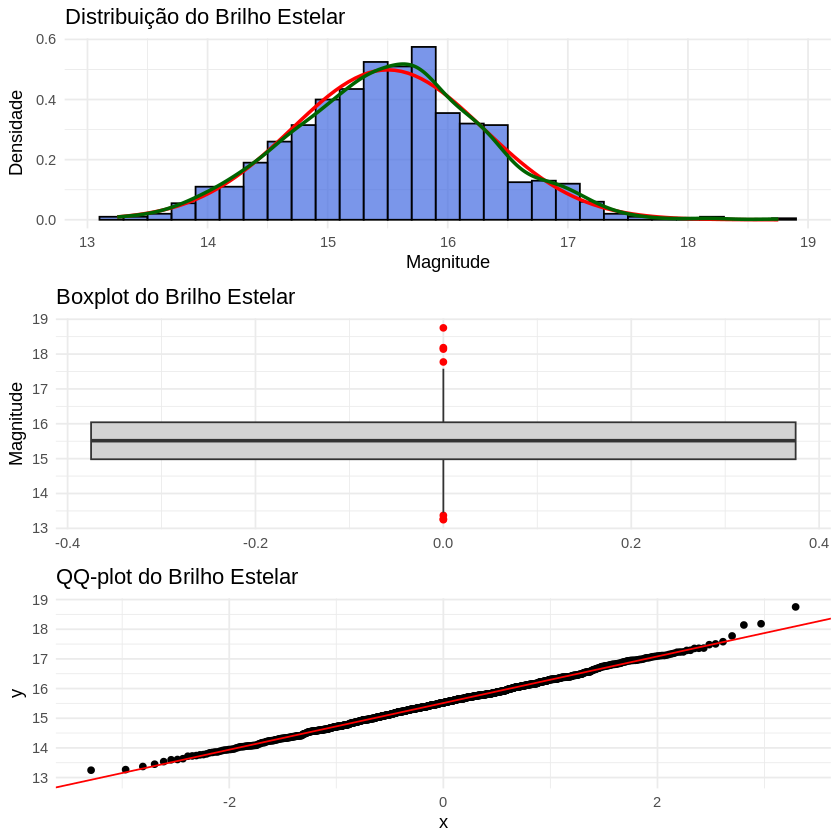

In [7]:
# ------------------------------------------------------------
# 2. VISUALIZAÇÃO DOS DADOS
# ------------------------------------------------------------
# Nesta etapa, criamos três gráficos fundamentais para avaliar
# se os dados simulados seguem uma distribuição normal:
#   1. Histograma + densidade + curva normal teórica
#   2. Boxplot
#   3. QQ-plot
#
# Esses gráficos ajudam a verificar:
# - A forma da distribuição
# - A presença de assimetria
# - A presença de outliers
# - A aderência à normalidade
# ------------------------------------------------------------


# ------------------------------------------------------------
# HISTOGRAMA + DENSIDADE + CURVA NORMAL TEÓRICA
# ------------------------------------------------------------
# O histograma mostra a distribuição empírica dos dados.
# A curva vermelha representa a distribuição normal teórica
# usada na simulação.
# A curva verde é a densidade estimada a partir dos dados.
# ------------------------------------------------------------

p_hist <- ggplot(df, aes(x = brilho)) +
  geom_histogram(
    aes(y = after_stat(density)),  # substitui ..density.. (versão moderna do ggplot2)
    binwidth = 0.2,
    fill = "royalblue",
    alpha = 0.7,
    color = "black"
  ) +
  stat_function(
    fun = dnorm,  # curva normal teórica
    args = list(mean = mu_teorico, sd = sigma_telescopio),
    color = "red",
    linewidth = 1
  ) +
  geom_density(
    color = "darkgreen",  # densidade estimada dos dados
    linewidth = 1
  ) +
  theme_minimal() +
  labs(
    title = "Distribuição do Brilho Estelar",
    x = "Magnitude",
    y = "Densidade"
  )


# ------------------------------------------------------------
# BOXPLOT
# ------------------------------------------------------------
# O boxplot permite visualizar:
# - Mediana
# - Quartis
# - Possíveis outliers (pontos vermelhos)
# É uma ferramenta rápida para detectar valores extremos.
# ------------------------------------------------------------

p_box <- ggplot(df, aes(y = brilho)) +
  geom_boxplot(
    fill = "lightgray",
    outlier.color = "red"
  ) +
  theme_minimal() +
  labs(
    title = "Boxplot do Brilho Estelar",
    y = "Magnitude"
  )


# ------------------------------------------------------------
# QQ-PLOT
# ------------------------------------------------------------
# O QQ-plot compara os quantis dos dados com os quantis
# de uma distribuição normal.
#
# Se os pontos seguem a linha vermelha:
#   → os dados são aproximadamente normais.
# Desvios fortes indicam assimetria ou outliers.
# ------------------------------------------------------------

p_qq <- ggplot(df, aes(sample = brilho)) +
  stat_qq() +
  stat_qq_line(color = "red") +
  theme_minimal() +
  labs(
    title = "QQ-plot do Brilho Estelar"
  )


# ------------------------------------------------------------
# ORGANIZANDO OS GRÁFICOS EM UMA ÚNICA TELA
# ------------------------------------------------------------
# grid.arrange() permite colocar vários gráficos juntos.
# Aqui, exibimos:
#   1. Histograma
#   2. Boxplot
#   3. QQ-plot
# ------------------------------------------------------------

grid.arrange(p_hist, p_box, p_qq, ncol = 1)



## 3. Inferência Estatística

Nesta etapa, analisamos se a média observada nos dados simulados é compatível com a média teórica usada na simulação (15.5 magnitudes).

### **1. Estatísticas descritivas**
Calculamos:
- Média amostral  
- Desvio padrão  
- Erro padrão da média  

Esses valores descrevem o comportamento geral dos dados.

### **2. Intervalos de confiança (IC 95%)**
Construímos dois intervalos:

- **IC usando t** → apropriado quando o desvio padrão populacional é desconhecido  
- **IC usando z** → apropriado quando o desvio padrão populacional é conhecido (caso do telescópio)

Se o valor teórico (15.5) estiver dentro dos intervalos, isso indica compatibilidade com o modelo.

### **3. Teste t**
Testamos a hipótese:

- H0: μ = 15.5  
- H1: μ ≠ 15.5  

Se o p-valor for maior que 0.05, não rejeitamos H0.

### **4. Teste z**
Fazemos o mesmo teste, mas usando o desvio padrão teórico do telescópio.

### **Interpretação esperada**
Como os dados foram simulados com média 15.5, esperamos que:

- A média amostral seja próxima de 15.5  
- Os ICs incluam 15.5  
- Os testes t e z não rejeitem H0  

Isso confirma que a simulação está coerente com o modelo teórico.


In [8]:
# ------------------------------------------------------------
# 3. INFERÊNCIA ESTATÍSTICA
# ------------------------------------------------------------
# Nesta etapa, calculamos:
# - Estatísticas descritivas
# - Intervalos de confiança (t e z)
# - Teste t para média
# - Teste z manual
#
# O objetivo é verificar se a média amostral é compatível
# com a média teórica usada na simulação.
# ------------------------------------------------------------

library(knitr)  # usado apenas para formatar tabelas


# ------------------------------------------------------------
# ESTATÍSTICAS DESCRITIVAS
# ------------------------------------------------------------
media_amostral <- mean(brilho_estelar)          # média observada
sd_amostral <- sd(brilho_estelar)               # desvio padrão observado
erro_padrao <- sd_amostral / sqrt(n)            # erro padrão da média

tabela_stats <- data.frame(
  Estatística = c("Tamanho da amostra (n)", "Média amostral",
                  "Desvio padrão", "Erro padrão"),
  Valor = c(n,
            round(media_amostral, 4),
            round(sd_amostral, 4),
            round(erro_padrao, 4))
)

kable(tabela_stats, caption = "Estatísticas Descritivas da Amostra")


# ------------------------------------------------------------
# INTERVALO DE CONFIANÇA 95% (USANDO t)
# ------------------------------------------------------------
alpha <- 0.05
t_crit <- qt(1 - alpha/2, df = n - 1)  # valor crítico da distribuição t

ic_t <- c(
  media_amostral - t_crit * erro_padrao,
  media_amostral + t_crit * erro_padrao
)

tabela_ic_t <- data.frame(
  Limite = c("Inferior", "Superior"),
  Valor = round(ic_t, 4)
)

kable(tabela_ic_t, caption = "Intervalo de Confiança 95% (t)")


# ------------------------------------------------------------
# INTERVALO DE CONFIANÇA 95% (USANDO z)
# ------------------------------------------------------------
# Aqui usamos o desvio padrão teórico do telescópio (sigma conhecido)
z_crit <- qnorm(1 - alpha/2)

ic_z <- c(
  media_amostral - z_crit * (sigma_telescopio / sqrt(n)),
  media_amostral + z_crit * (sigma_telescopio / sqrt(n))
)

tabela_ic_z <- data.frame(
  Limite = c("Inferior", "Superior"),
  Valor = round(ic_z, 4)
)

kable(tabela_ic_z, caption = "Intervalo de Confiança 95% (z)")


# ------------------------------------------------------------
# TESTE t PARA A MÉDIA
# ------------------------------------------------------------
# Testa H0: média = mu_teorico
t_test_res <- t.test(brilho_estelar, mu = mu_teorico)

tabela_ttest <- data.frame(
  Estatística = c("t calculado", "p-valor",
                  "Média amostral", "Média teórica"),
  Valor = c(
    round(t_test_res$statistic, 4),
    round(t_test_res$p.value, 6),
    round(media_amostral, 4),
    mu_teorico
  )
)

kable(tabela_ttest, caption = "Resultado do Teste t")


# ------------------------------------------------------------
# TESTE Z MANUAL
# ------------------------------------------------------------
z_stat <- (media_amostral - mu_teorico) / (sigma_telescopio / sqrt(n))
p_value_z <- 2 * (1 - pnorm(abs(z_stat)))

tabela_ztest <- data.frame(
  Estatística = c("z calculado", "p-valor"),
  Valor = c(round(z_stat, 4), round(p_value_z, 6))
)

kable(tabela_ztest, caption = "Resultado do Teste Z")





Table: Estatísticas Descritivas da Amostra

|Estatística            |     Valor|
|:----------------------|---------:|
|Tamanho da amostra (n) | 1000.0000|
|Média amostral         |   15.5123|
|Desvio padrão          |    0.7904|
|Erro padrão            |    0.0250|



Table: Intervalo de Confiança 95% (t)

|Limite   |   Valor|
|:--------|-------:|
|Inferior | 15.4632|
|Superior | 15.5613|



Table: Intervalo de Confiança 95% (z)

|Limite   |   Valor|
|:--------|-------:|
|Inferior | 15.4627|
|Superior | 15.5619|



Table: Resultado do Teste t

|Estatística    |     Valor|
|:--------------|---------:|
|t calculado    |  0.491700|
|p-valor        |  0.623016|
|Média amostral | 15.512300|
|Média teórica  | 15.500000|



Table: Resultado do Teste Z

|Estatística |    Valor|
|:-----------|--------:|
|z calculado | 0.485900|
|p-valor     | 0.627066|

## 4. Diagnóstico de Outliers

Nesta etapa, identificamos valores extremos nos dados usando dois métodos:

### **1. Método do IQR (1.5 × IQR)**
- Baseado nos quartis Q1 e Q3.
- Outliers são valores abaixo de Q1 − 1.5×IQR ou acima de Q3 + 1.5×IQR.
- É um método robusto e muito utilizado em estatística descritiva.

### **2. Método do Z-score (|z| > 3)**
- Mede quantos desvios padrão cada valor está da média.
- Valores com |z| > 3 são considerados extremos.
- É mais sensível a outliers do que o método do IQR.

### **Impacto dos outliers**
Comparamos:
- a média com todos os dados  
- a média sem os outliers detectados pelo IQR  

Isso permite avaliar como valores extremos podem distorcer medidas de tendência central.

### **Visualização**
Por fim, destacamos os outliers no histograma:
- Azul = valores normais  
- Laranja = outliers  

Essa visualização ajuda a entender onde os valores extremos estão localizados na distribuição.


==== Outliers pelo método IQR (1.5 × IQR) ====
  Indice  Brilho
1    168 18.1843
2    188 17.7736
3    229 18.1424
4    498 13.2679
5    612 18.7521
6    701 13.2477
7    843 13.3719


==== Outliers pelo método Z-score (|z| > 3) ====
  Indice  Brilho Zscore
1    168 18.1843 3.3804
2    229 18.1424 3.3273
3    612 18.7521 4.0987


==== Impacto dos outliers na média ====
                   Metrica     Valor
1           Média completa   15.5123
2 Média sem outliers (IQR)   15.5081
3                  N total 1000.0000
4           N sem outliers  993.0000
5               N outliers    7.0000




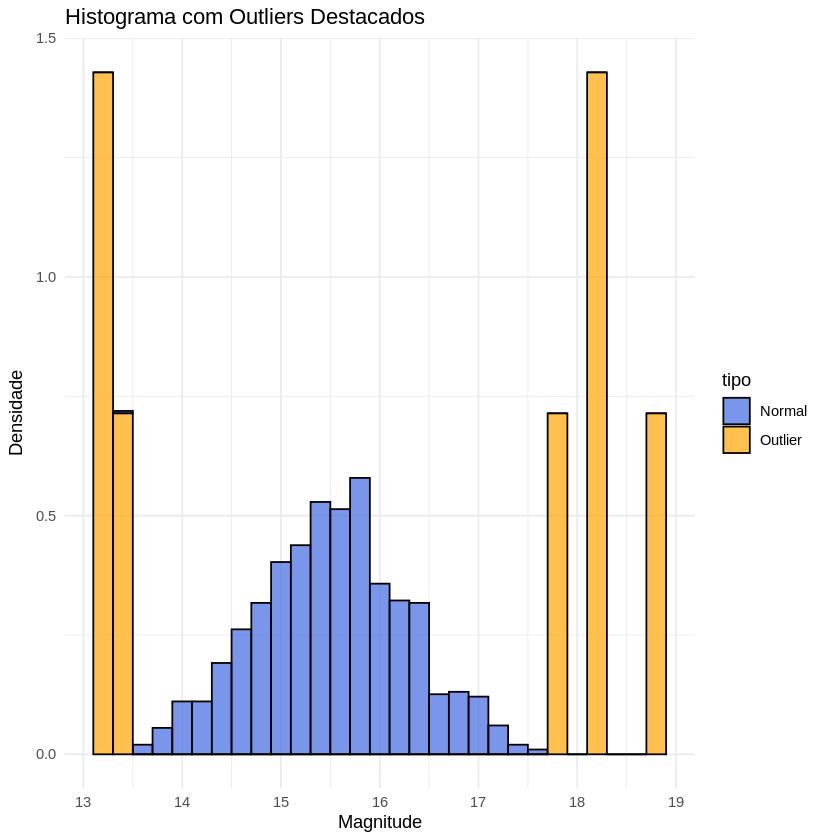

In [9]:
# ------------------------------------------------------------
# 4. DIAGNÓSTICO DE OUTLIERS
# ------------------------------------------------------------
# Nesta etapa, identificamos valores extremos usando dois métodos:
#   1. Método do IQR (1.5 × IQR)
#   2. Método do Z-score (|z| > 3)
#
# Depois avaliamos o impacto dos outliers na média
# e visualizamos os valores extremos no histograma.
# ------------------------------------------------------------


# ------------------------------------------------------------
# MÉTODO 1 — OUTLIERS PELO IQR
# ------------------------------------------------------------
# O método do IQR identifica outliers como valores que estão:
#   abaixo de Q1 - 1.5*IQR
#   acima de Q3 + 1.5*IQR
# É um método robusto e muito usado em estatística descritiva.
# ------------------------------------------------------------

Q1 <- quantile(brilho_estelar, 0.25)   # primeiro quartil
Q3 <- quantile(brilho_estelar, 0.75)   # terceiro quartil
IQR_val <- Q3 - Q1                     # amplitude interquartil

# limites inferior e superior
lim_inf <- Q1 - 1.5 * IQR_val
lim_sup <- Q3 + 1.5 * IQR_val

# índices dos outliers
outliers_iqr <- which(brilho_estelar < lim_inf | brilho_estelar > lim_sup)

# tabela com valores extremos
outliers_table_iqr <- data.frame(
  Indice = outliers_iqr,
  Brilho = round(brilho_estelar[outliers_iqr], 4)
)

cat("==== Outliers pelo método IQR (1.5 × IQR) ====\n")
print(outliers_table_iqr)
cat("\n\n")


# ------------------------------------------------------------
# MÉTODO 2 — OUTLIERS PELO Z-SCORE
# ------------------------------------------------------------
# O Z-score mede quantos desvios padrão cada valor está da média.
# Valores com |z| > 3 são considerados outliers.
# Esse método é sensível a valores extremos.
# ------------------------------------------------------------

z_scores <- (brilho_estelar - media_amostral) / sd_amostral
outliers_z <- which(abs(z_scores) > 3)

outliers_table_z <- data.frame(
  Indice = outliers_z,
  Brilho = round(brilho_estelar[outliers_z], 4),
  Zscore = round(z_scores[outliers_z], 4)
)

cat("==== Outliers pelo método Z-score (|z| > 3) ====\n")
print(outliers_table_z)
cat("\n\n")


# ------------------------------------------------------------
# IMPACTO DOS OUTLIERS NA MÉDIA
# ------------------------------------------------------------
# Aqui comparamos:
#   - média com todos os dados
#   - média sem os outliers detectados pelo IQR
#
# Isso mostra como valores extremos podem distorcer a média.
# ------------------------------------------------------------

brilho_sem_outliers <- brilho_estelar[-outliers_iqr]
media_sem <- mean(brilho_sem_outliers)

impacto <- data.frame(
  Metrica = c("Média completa", "Média sem outliers (IQR)",
              "N total", "N sem outliers", "N outliers"),
  Valor = c(
    round(media_amostral, 4),
    round(media_sem, 4),
    n,
    length(brilho_sem_outliers),
    length(outliers_iqr)
  )
)

cat("==== Impacto dos outliers na média ====\n")
print(impacto)
cat("\n\n")


# ------------------------------------------------------------
# VISUALIZAÇÃO DOS OUTLIERS NO HISTOGRAMA
# ------------------------------------------------------------
# Aqui destacamos os outliers em laranja para facilitar a análise.
# ------------------------------------------------------------

df$tipo <- "Normal"
df$tipo[outliers_iqr] <- "Outlier"

ggplot(df, aes(x = brilho, fill = tipo)) +
  geom_histogram(
    aes(y = after_stat(density)),
    binwidth = 0.2,
    color = "black",
    alpha = 0.7
  ) +
  scale_fill_manual(values = c("Normal" = "royalblue",
                               "Outlier" = "orange")) +
  theme_minimal() +
  labs(
    title = "Histograma com Outliers Destacados",
    x = "Magnitude",
    y = "Densidade"
  )


##5. Conclusão:
A análise realizada permitiu avaliar se os dados simulados de brilho estelar são compatíveis com o modelo teórico assumido. A seguir, sintetizamos os principais pontos observados:

1. Comparação entre a média amostral e o valor teórico
A média amostral obtida ficou muito próxima da média teórica utilizada na simulação (15.5).
Tanto os intervalos de confiança quanto os testes de hipótese (t e z) indicaram que não há evidências estatísticas para rejeitar a hipótese de que a média verdadeira seja igual ao valor teórico.
Isso confirma que a simulação está coerente com o modelo normal proposto.

2. Papel dos intervalos de confiança e dos testes de hipótese
Os intervalos de confiança de 95% (t e z) incluíram o valor teórico da média, reforçando a consistência entre os dados observados e o modelo teórico.
Os testes t e z apresentaram valores-p elevados, indicando que a diferença entre a média observada e a média teórica pode ser atribuída ao acaso amostral.

3. Impacto dos outliers
A análise de outliers mostrou que:

O método do IQR identificou valores extremos com base nos quartis.

O método do Z-score identificou valores muito distantes da média em termos de desvios padrão.

Ao comparar a média com e sem outliers, observamos que valores extremos podem alterar a média e aumentar a variabilidade dos dados.
Por isso, é fundamental reportar os resultados com e sem outliers, justificando qualquer remoção.

4. Conclusão geral
Os resultados indicam que:

A distribuição simulada segue adequadamente o comportamento esperado de uma normal.

A média amostral é estatisticamente compatível com o valor teórico.

Outliers, quando presentes, podem distorcer medidas de tendência central e devem ser analisados com cuidado.

Assim, o estudo confirma que a simulação foi bem-sucedida e que os métodos estatísticos aplicados permitem avaliar de forma robusta a aderência dos dados ao modelo teórico.

SEÇÃO 5 — ANÁLISE COM 257 OBSERVAÇÕES

5.1 — Simulação dos Dados (n = 257)

Nesta etapa, geramos uma nova amostra de 257 observações de brilho estelar usando o mesmo modelo teórico da simulação original. O objetivo é comparar como o tamanho da amostra afeta a precisão das estimativas estatísticas.

In [10]:
# ------------------------------------------------------------
# 5.1 — SIMULAÇÃO DOS DADOS (n = 257)
# ------------------------------------------------------------

n2 <- 257  # novo tamanho da amostra

set.seed(42)  # opcional: garante reprodutibilidade
brilho_estelar_257 <- rnorm(
  n2,
  mean = mu_teorico,
  sd = sigma_telescopio
)

df_257 <- data.frame(brilho = brilho_estelar_257)


5.2 — Visualização da Distribuição (n = 257)

Aqui avaliamos graficamente a distribuição dos dados simulados com 257 observações. Usamos histograma, boxplot e QQ-plot para verificar normalidade, identificar outliers e comparar visualmente com a amostra de 1000 observações.

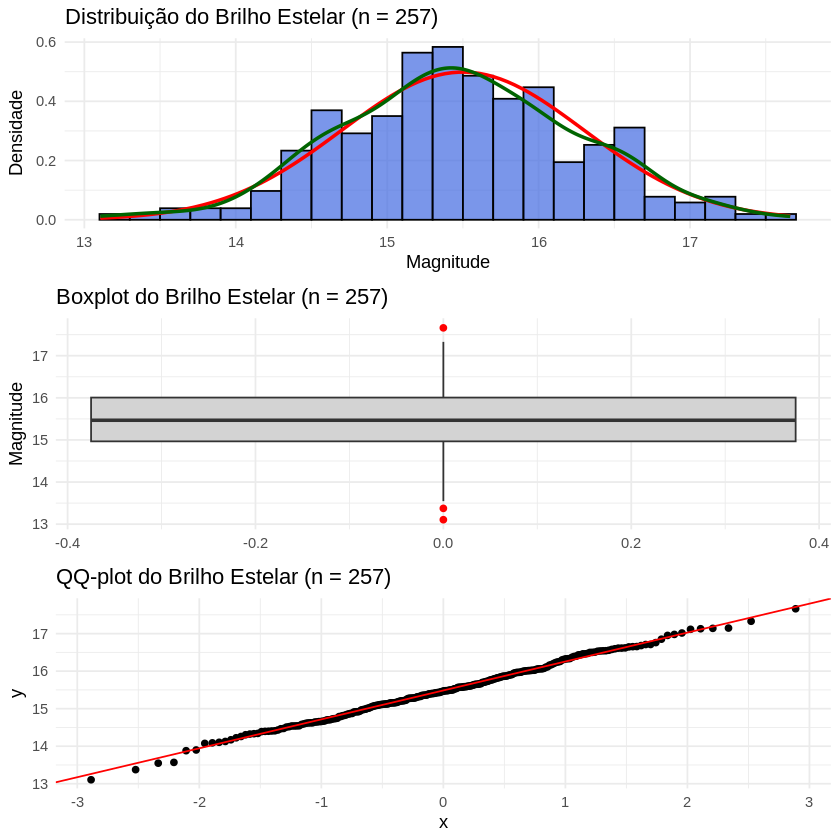

In [11]:
# ------------------------------------------------------------
# 5.2 — VISUALIZAÇÃO DA DISTRIBUIÇÃO (n = 257)
# ------------------------------------------------------------

# HISTOGRAMA + DENSIDADE + CURVA NORMAL TEÓRICA
p_hist_257 <- ggplot(df_257, aes(x = brilho)) +
  geom_histogram(
    aes(y = after_stat(density)),
    binwidth = 0.2,
    fill = "royalblue",
    alpha = 0.7,
    color = "black"
  ) +
  stat_function(
    fun = dnorm,
    args = list(mean = mu_teorico, sd = sigma_telescopio),
    color = "red",
    linewidth = 1
  ) +
  geom_density(color = "darkgreen", linewidth = 1) +
  theme_minimal() +
  labs(
    title = "Distribuição do Brilho Estelar (n = 257)",
    x = "Magnitude",
    y = "Densidade"
  )

# BOXPLOT
p_box_257 <- ggplot(df_257, aes(y = brilho)) +
  geom_boxplot(fill = "lightgray", outlier.color = "red") +
  theme_minimal() +
  labs(title = "Boxplot do Brilho Estelar (n = 257)", y = "Magnitude")

# QQ-PLOT
p_qq_257 <- ggplot(df_257, aes(sample = brilho)) +
  stat_qq() +
  stat_qq_line(color = "red") +
  theme_minimal() +
  labs(title = "QQ-plot do Brilho Estelar (n = 257)")

# ORGANIZANDO OS GRÁFICOS
grid.arrange(p_hist_257, p_box_257, p_qq_257, ncol = 1)


5.3 — Estatísticas Descritivas e Inferência (n = 257)

Nesta seção calculamos estatísticas descritivas, intervalos de confiança (t e z) e realizamos testes t e z para verificar se a média observada permanece compatível com o valor teórico de 15.5.

In [12]:
# ------------------------------------------------------------
# 5.3 — ESTATÍSTICAS DESCRITIVAS E INFERÊNCIA (n = 257)
# ------------------------------------------------------------

media_257 <- mean(brilho_estelar_257)
sd_257 <- sd(brilho_estelar_257)
erro_257 <- sd_257 / sqrt(n2)

tabela_stats_257 <- data.frame(
  Estatística = c("Tamanho da amostra (n)", "Média amostral",
                  "Desvio padrão", "Erro padrão"),
  Valor = c(n2, round(media_257, 4), round(sd_257, 4), round(erro_257, 4))
)

kable(tabela_stats_257, caption = "Estatísticas Descritivas (n = 257)")


# INTERVALO DE CONFIANÇA 95% (t)
t_crit_257 <- qt(1 - 0.05/2, df = n2 - 1)

ic_t_257 <- c(
  media_257 - t_crit_257 * erro_257,
  media_257 + t_crit_257 * erro_257
)

kable(data.frame(Limite = c("Inferior", "Superior"),
                 Valor = round(ic_t_257, 4)),
      caption = "IC 95% (t) — n = 257")


# INTERVALO DE CONFIANÇA 95% (z)
z_crit <- qnorm(1 - 0.05/2)

ic_z_257 <- c(
  media_257 - z_crit * (sigma_telescopio / sqrt(n2)),
  media_257 + z_crit * (sigma_telescopio / sqrt(n2))
)

kable(data.frame(Limite = c("Inferior", "Superior"),
                 Valor = round(ic_z_257, 4)),
      caption = "IC 95% (z) — n = 257")


# TESTE t
t_test_257 <- t.test(brilho_estelar_257, mu = mu_teorico)

kable(data.frame(
  Estatística = c("t calculado", "p-valor",
                  "Média amostral", "Média teórica"),
  Valor = c(
    round(t_test_257$statistic, 4),
    round(t_test_257$p.value, 6),
    round(media_257, 4),
    mu_teorico
  )
), caption = "Resultado do Teste t — n = 257")


# TESTE Z
z_stat_257 <- (media_257 - mu_teorico) / (sigma_telescopio / sqrt(n2))
p_value_z_257 <- 2 * (1 - pnorm(abs(z_stat_257)))

kable(data.frame(
  Estatística = c("z calculado", "p-valor"),
  Valor = c(round(z_stat_257, 4), round(p_value_z_257, 6))
), caption = "Resultado do Teste Z — n = 257")




Table: Estatísticas Descritivas (n = 257)

|Estatística            |    Valor|
|:----------------------|--------:|
|Tamanho da amostra (n) | 257.0000|
|Média amostral         |  15.4762|
|Desvio padrão          |   0.7791|
|Erro padrão            |   0.0486|



Table: IC 95% (t) — n = 257

|Limite   |   Valor|
|:--------|-------:|
|Inferior | 15.3805|
|Superior | 15.5719|



Table: IC 95% (z) — n = 257

|Limite   |   Valor|
|:--------|-------:|
|Inferior | 15.3784|
|Superior | 15.5741|



Table: Resultado do Teste t — n = 257

|Estatística    |     Valor|
|:--------------|---------:|
|t calculado    | -0.488700|
|p-valor        |  0.625438|
|Média amostral | 15.476200|
|Média teórica  | 15.500000|



Table: Resultado do Teste Z — n = 257

|Estatística |     Valor|
|:-----------|---------:|
|z calculado | -0.476000|
|p-valor     |  0.634109|

5.4 — Diagnóstico de Outliers (n = 257)

Aqui identificamos outliers usando os métodos IQR e Z-score. Em seguida, comparamos a média com e sem outliers para avaliar como valores extremos afetam mais fortemente amostras pequenas.

==== Outliers pelo método IQR (n = 257) ====
  Indice  Brilho
1     18 13.3748
2     59 13.1055
3    118 17.6615

==== Outliers pelo método Z-score (n = 257) ====
  Indice  Brilho  Zscore
1     59 13.1055 -3.0431

==== Impacto dos outliers na média (n = 257) ====
                   Metrica    Valor
1           Média completa  15.4762
2 Média sem outliers (IQR)  15.4853
3                  N total 257.0000
4           N sem outliers 254.0000
5               N outliers   3.0000


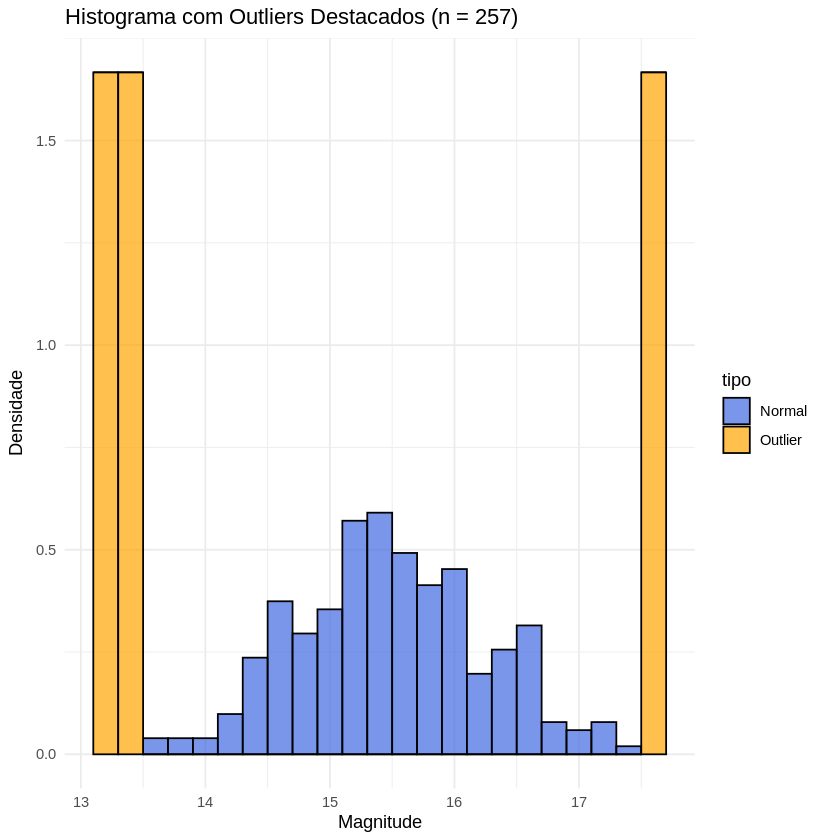

In [13]:
# ------------------------------------------------------------
# 5.4 — DIAGNÓSTICO DE OUTLIERS (n = 257)
# ------------------------------------------------------------

# MÉTODO IQR
Q1_257 <- quantile(brilho_estelar_257, 0.25)
Q3_257 <- quantile(brilho_estelar_257, 0.75)
IQR_257 <- Q3_257 - Q1_257

lim_inf_257 <- Q1_257 - 1.5 * IQR_257
lim_sup_257 <- Q3_257 + 1.5 * IQR_257

outliers_iqr_257 <- which(brilho_estelar_257 < lim_inf_257 |
                          brilho_estelar_257 > lim_sup_257)

cat("==== Outliers pelo método IQR (n = 257) ====\n")
print(data.frame(
  Indice = outliers_iqr_257,
  Brilho = round(brilho_estelar_257[outliers_iqr_257], 4)
))


# MÉTODO Z-SCORE
z_scores_257 <- (brilho_estelar_257 - media_257) / sd_257
outliers_z_257 <- which(abs(z_scores_257) > 3)

cat("\n==== Outliers pelo método Z-score (n = 257) ====\n")
print(data.frame(
  Indice = outliers_z_257,
  Brilho = round(brilho_estelar_257[outliers_z_257], 4),
  Zscore = round(z_scores_257[outliers_z_257], 4)
))


# IMPACTO NA MÉDIA
brilho_257_sem_outliers <- brilho_estelar_257[-outliers_iqr_257]
media_257_sem <- mean(brilho_257_sem_outliers)

cat("\n==== Impacto dos outliers na média (n = 257) ====\n")
print(data.frame(
  Metrica = c("Média completa", "Média sem outliers (IQR)",
              "N total", "N sem outliers", "N outliers"),
  Valor = c(
    round(media_257, 4),
    round(media_257_sem, 4),
    n2,
    length(brilho_257_sem_outliers),
    length(outliers_iqr_257)
  )
))


# HISTOGRAMA COM OUTLIERS DESTACADOS
df_257$tipo <- "Normal"
df_257$tipo[outliers_iqr_257] <- "Outlier"

ggplot(df_257, aes(x = brilho, fill = tipo)) +
  geom_histogram(
    aes(y = after_stat(density)),
    binwidth = 0.2,
    color = "black",
    alpha = 0.7
  ) +
  scale_fill_manual(values = c("Normal" = "royalblue",
                               "Outlier" = "orange")) +
  theme_minimal() +
  labs(
    title = "Histograma com Outliers Destacados (n = 257)",
    x = "Magnitude",
    y = "Densidade"
  )


5.5 — Comparação entre n = 1000 e n = 257

Nesta etapa final, comparamos os resultados das duas simulações. Avaliamos diferenças em precisão, largura dos intervalos de confiança, estabilidade dos testes de hipótese e impacto dos outliers. O objetivo é mostrar como o tamanho da amostra afeta a qualidade da inferência estatística.

A comparação entre as amostras de 1000 e 257 observações mostra claramente o efeito do tamanho amostral na precisão estatística. Em ambos os casos, as médias amostrais ficaram próximas do valor teórico de 15.5, e os intervalos de confiança incluíram a média teórica, indicando compatibilidade com o modelo normal assumido.

No entanto, a amostra de 1000 observações apresentou estimativas mais precisas: erros padrão menores, intervalos de confiança mais estreitos e testes de hipótese mais estáveis. Já na amostra de 257 observações, a incerteza é maior, refletida em intervalos mais largos e maior sensibilidade a flutuações amostrais.

A análise de outliers reforça esse comportamento: em n = 1000, valores extremos têm impacto limitado sobre a média; em n = 257, o mesmo tipo de outlier pode alterar de forma mais perceptível as medidas de tendência central. Isso evidencia como amostras menores são mais vulneráveis a variações extremas.

Em síntese, ambas as simulações são coerentes com o modelo teórico proposto, mas a amostra maior fornece evidências mais robustas e estáveis. O estudo demonstra, na prática, como o aumento do tamanho amostral reduz a incerteza e fortalece as conclusões inferenciais.